<a href="https://colab.research.google.com/github/himabindusgs-svg/LinearRegression/blob/main/CAPSTONE%20PROJECT%20ASSESSMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:

   Study_Hours  Attendance  Assignments  Marks
0            2          50            3     40
1            3          55            4     48
2            4          60            5     55
3            5          70            6     65
4            6          75            7     72
5            7          80            8     80
6            8          90            9     88


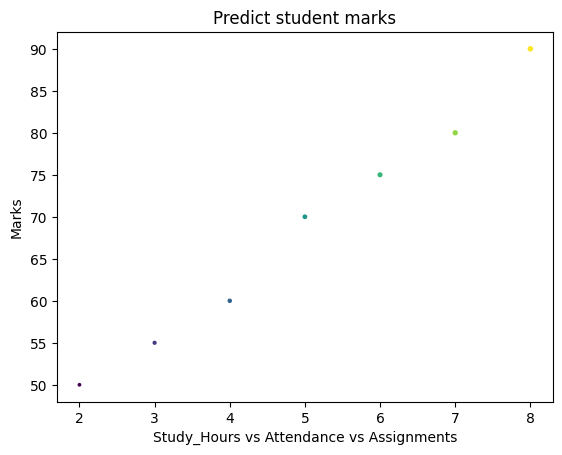


Predicted Marks based upon :

[72.75047619]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


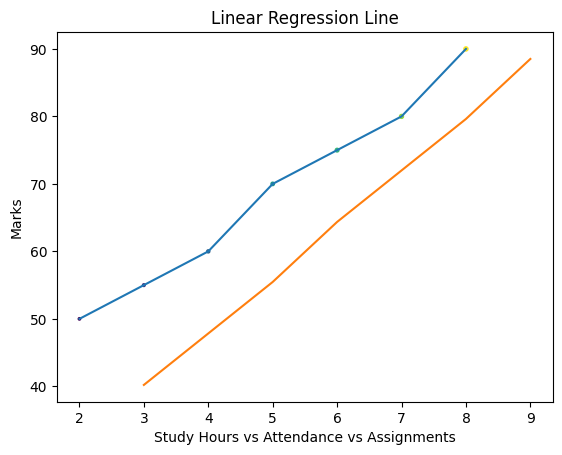

In [7]:
# TASK 1 — STUDENT MARKS PREDICTION
# (Linear Regression)
# The university wants to predict student marks based on:
# Study Hours
# Attendance Percentage
# Assignment Completion Count
# Tasks
# Load the dataset using Pandas.
# Separate input and output variables.
# Train a Linear Regression model.
# Predict marks for:
# Study Hours = 6
# Attendance = 78
# Assignments = 7
# Display predicted marks.


import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.linear_model import LinearRegression


# STEP 2 — Upload CSV file

uploaded = files.upload()

# STEP 3 — Load dataset

df = pd.read_csv("Student.csv")


# STEP 4 — Display dataset

print("Dataset:\n")
print(df)


# STEP 5 — Visualize the data

plt.scatter(df['Study_Hours'], df['Attendance'], df['Assignments'], df['Marks'])

plt.xlabel("Study_Hours vs Attendance vs Assignments")
plt.ylabel("Marks")

plt.title("Predict student marks")

plt.show()


# STEP 6 — Prepare input and output data

X = df[['Study_Hours', 'Attendance', 'Assignments']]  # Input
y = df['Marks']          # Output


# STEP 7 — Create Linear Regression model
model = LinearRegression()


# STEP 8 — Train the model

model.fit(X, y)


# STEP 9 — Predicted Marks

prediction = model.predict([[6,78,7]])

print("\nPredicted Marks based upon Study_Hours, Attendance and Assignments  :\n")
print(prediction)


# STEP 10 — Draw Regression Line

plt.scatter(df['Study_Hours'], df['Attendance'], df['Assignments'], df['Marks'])

plt.plot(df['Study_Hours'], df['Attendance'], df['Assignments'], model.predict(X))

plt.xlabel("Study Hours vs Attendance vs Assignments")
plt.ylabel("Marks")

plt.title("Linear Regression Line")

plt.show()




# TASK 2 — STUDENT RISK CLASSIFICATION
# (Logistic Regression)
# The university wants to identify whether a student is:
# At Risk
# Safe
# based on:
# Attendance
# Internal Assessment Score

# Label Meaning
# Result
# Meaning
# 0
# At Risk
# 1
# Safe


# Tasks
# Train a Logistic Regression model.
# Predict student status for:
# Attendance = 68
# Internal Score = 60
# Display whether the student is:
# At Risk
# Safe

import pandas as pd
from sklearn.linear_model import LogisticRegression

data = {

'Attendance':[40,45,50,60,70,80,90],

'Internal Score':[35,38,40,55,65,75,85],

'Result':[0,0,0,1,1,1,1]

}

df=pd.DataFrame(data)

X=df[['Attendance', 'Internal Score']]

y=df['Result']

model=LogisticRegression()

model.fit(X,y)

prediction=model.predict([[68,60]])

print(prediction)

if (prediction==0):
  print("The student is At Risk")
else:
  print("The student is Safe")









# TASK 3 — STUDENT ENGAGEMENT SEGMENTATION

# STUDENT ENGAGEMENT SEGMENTATION

# (K-Means Clustering)
# The university wants to group students into:
# Low Engagement
# Medium Engagement
# High Engagement
# based on:
# LMS Usage Hours
# Library Visits
# Attendance
# Tasks
# Train a K-Means model with 3 clusters.
# Predict clusters for students.
# Assign cluster labels:
# Low Engagement
# Medium Engagement
# High Engagement
# Visualize clusters using Matplotlib.


import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)


# ============================================
# Create Dataset
# ============================================

# STEP 2 — Upload CSV file

uploaded = files.upload()


# STEP 3 — Load dataset

df = pd.read_csv("StudentEngagement.csv")


# STEP 4 — Display dataset

print("Dataset:\n")
print(df)


print(df)

# ============================================
# Select Input Features
# ============================================

X = df[['LMS_Hours','Library_Visits', 'Attendance']]


# ============================================
# Train K-Means
# ============================================

model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(X)


# ============================================
# Predict Clusters
# ============================================

predicted = model.labels_
df['Predicted'] = predicted


print("\nPredicted Clusters\n")

print(predicted)


# ============================================
# IMPORTANT:
# K-Means labels are random
# ============================================

print("\nCluster Centers\n")

print(model.cluster_centers_)


# Actual learned clusters:

# Cluster 2 → Low
# Cluster 0 → Medium
# Cluster 1 → High


cluster_mapping = {

2:0,
0:1,
1:2

}


df['Mapped_Predicted'] = (
    df['Predicted']
    .map(cluster_mapping)
)
# Human-friendly labels

activity_map = {

0:'Low Activity',
1:'Medium Activity',
2:'High Activity'

}


df['Activity_Level']=(
    df['Mapped_Predicted']
    .map(activity_map)
)


print("\nUpdated Dataset\n")

print(df)


# ============================================
# Evaluation
# ============================================

accuracy = accuracy_score(

    df['Attendance'],

    df['Mapped_Predicted']

)


precision = precision_score(

    df['Attendance'],

    df['Mapped_Predicted'],

    average='macro'
    )


recall = recall_score(

    df['Attendance'],

    df['Mapped_Predicted'],

    average='macro'

)


print("\nAccuracy:",accuracy)

print("Precision:",precision)

print("Recall:",recall)


# ============================================
# Visualization
# ============================================

plt.scatter(

    df['LMS_Hours'],

    df['Library_Visits'],

    c=df['Attendance']

)

plt.xlabel("LMS_Hours vs Library Visits vs Attendence")

plt.ylabel("Students")

plt.title(
    "STUDENT ENGAGEMENT SEGMENTATION"
    )

plt.show()





# 4 STUDENT FEEDBACK SENTIMENT ANALYZER

# (NLP)
# The university receives feedback comments from students.
# The administration wants AI to identify whether comments are:
# Positive
# Negative
# Neutral

# Sample Feedback
# Feedback
# “Faculty support is excellent”
# “Assignments are stressful”
# “Labs are average”


# Tasks
# Tokenize the feedback sentence.
# Remove stopwords.
# Use SentimentIntensityAnalyzer.
# Display sentiment scores.
# Display final sentiment category.

# STEP 1 — Import Libraries

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer


nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# STEP 2 — Download Required NLTK Data

nltk.download('punkt_tab')
nltk.download('stopwords')


# Input Customer Review

Feedback = "Faculty support is excellent. Assignments are stressful. And Labs are average."


# Tokenization

tokens = word_tokenize(Feedback)

print(tokens)


# Stopwords Removal

stop_words = set(stopwords.words('english'))

filtered_words = []

for word in tokens:

    if word.lower() not in stop_words:

        filtered_words.append(word)

print(filtered_words)


# Sentiment Analysis
sia = SentimentIntensityAnalyzer()

score = sia.polarity_scores(Feedback)

print("score is ")

print(score)

# Final Prediction

compound = score['compound']

print(" compound is " + str(compound))
print ("Final sentiment category is ")

if compound >= 0.05:

    print("Positive Review")

elif compound <= -0.05:

    print("Negative Review")

else:

    print("Neutral Review")



# 5 HANDWRITTEN STUDENT ID RECOGNIZER

# (Computer Vision + CNN)
# The university wants AI to recognize handwritten student ID digits from uploaded images.

# Tasks
# Load MNIST dataset.
# Normalize images.
# Build a CNN model.
# Train the model.
# Predict handwritten digit from test dataset.
# Upload an external handwritten image.
# Preprocess image:
# grayscale
# resize
# normalize
# Predict uploaded digit.
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Step 1: Upload External Handwritten Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Step 2: Load or Train MNIST Model
try:
    # Try loading a saved model
    model = load_model("mnist_model.h5")
    print("Loaded pre-trained MNIST model.")
except:
    print("No saved model found. Training a new one...")
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    # Reshape and normalize
    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)

    # Build CNN model
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    model.fit(x_train, y_train, epochs=6, batch_size=128, validation_data=(x_test, y_test))

    # Save model for reuse
    model.save("mnist_model.h5")

# Step 3: Preprocess Uploaded Image
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = 255 - gray   # invert colors (white background, black digit)
resized = cv2.resize(gray, (28, 28))
plt.imshow(resized, cmap="gray")
plt.title("Processed Handwritten Digit")
plt.axis("off")
plt.show()

# Normalize and reshape
resized = resized / 255.0
input_image = resized.reshape(1, 28, 28, 1)

# Step 4: Predict Digit
prediction = model.predict(input_image)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)



# TASK 6 — MODEL EVALUATION
# The university wants to measure AI model performance.

# Tasks
# For Classification Models:
# Calculate:
# Accuracy
# Precision
# Recall
# Explain:
# What does high precision mean?
# What does high recall mean?


Ranks Based upon Attendance vs Library visits:

Accuracy : Total number of class hours (100%)

If the student attended 75% of the class time, accuracy is 75/100 = 75%


Precision: Measures how accurate the model is.

Recall : Finds out all relevant instances






# TASK 7 — FINAL ANALYSIS QUESTIONS

# FINAL ANALYSIS QUESTIONS
# Answer the following:
Which AI model was used for:
prediction?

To predict an external image using MNIST model.

classification?
Is in Supervised learning AI models. Logistic Regression, Decision Trees

clustering?
K Means clustering

image recognition?
Deep learning models. computer vision (CV model)

Why is preprocessing important in AI projects?
To prepare the data ready to use

Why can AI predictions sometimes be incorrect?
If the data is wrong or not enough epochs to train the model

What is the difference between:
Linear Regression

is used to predict a number.

Logistic Regression
is used to predict the categories.

K-Means Clustering
is used to automatically create groups of similar customers based upon the patterns.


Which module did you find most useful and why?

Each model is equally important depends on the requirement.


